In [1]:
from pathlib import Path
from collections import defaultdict
import zipfile
import hashlib
import shutil
import random
import math
import csv

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split

In [2]:
ZIP_PATH = Path("PBC_dataset_normal_DIB.zip")

EXTRACT_DIR = Path("pbc_extracted")

OUTPUT_DIR = Path("PBC_balanced_notebook")

TARGET_WIDTH = 360
TARGET_HEIGHT = 363

TEST_RATIO = 0.20
VAL_RATIO = 0.10

SEED = 42

TARGET_COUNT = None

OVERWRITE_OUTPUT = True

random.seed(SEED)
np.random.seed(SEED)

In [4]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def is_valid_image_path(path: Path) -> bool:
    name = path.name.lower()

    if path.suffix.lower() not in IMAGE_EXTS:
        return False

    if "__macosx" in str(path).lower():
        return False

    if name.startswith("._"):
        return False

    if name.startswith(".ds_") or name == ".ds_store":
        return False

    return True


def find_dataset_root(base_dir: Path) -> Path:
    """
    It automatically locates the main folder containing class folders.
    Class folder = subfolder containing image files.
    """
    candidates = []

    for d in base_dir.rglob("*"):
        if not d.is_dir():
            continue

        child_dirs = [x for x in d.iterdir() if x.is_dir()]
        image_child_dirs = []

        for child in child_dirs:
            has_img = any(
                p.is_file() and is_valid_image_path(p)
                for p in child.iterdir()
            )

            if has_img:
                image_child_dirs.append(child)

        if len(image_child_dirs) >= 2:
            candidates.append((d, len(image_child_dirs)))

    if not candidates:
        raise RuntimeError("Class folders containing image files not found.")

    candidates = sorted(candidates, key=lambda x: x[1], reverse=True)
    return candidates[0][0]


# ZIP aç
if ZIP_PATH.exists():
    if EXTRACT_DIR.exists():
        shutil.rmtree(EXTRACT_DIR)

    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)

    DATASET_DIR = find_dataset_root(EXTRACT_DIR)

else:
    raise FileNotFoundError(f"ZIP not found: {ZIP_PATH}")

print("Data set folder:", DATASET_DIR)

class_dirs = sorted([d for d in DATASET_DIR.iterdir() if d.is_dir()])
print("Classes:")
for d in class_dirs:
    print("-", d.name)

Data set folder: pbc_extracted/PBC_dataset_normal_DIB/PBC_dataset_normal_DIB
Classes:
- basophil
- eosinophil
- erythroblast
- ig
- lymphocyte
- monocyte
- neutrophil
- platelet


Readable image count: 17092
Unreadable file count: 0


,path,class,width,height,channels
0,pbc_extracted/PBC_dataset_normal_DIB/PBC_datas...,lymphocyte,360,363,3
1,pbc_extracted/PBC_dataset_normal_DIB/PBC_datas...,lymphocyte,360,363,3
2,pbc_extracted/PBC_dataset_normal_DIB/PBC_datas...,lymphocyte,360,363,3
3,pbc_extracted/PBC_dataset_normal_DIB/PBC_datas...,lymphocyte,366,369,3
4,pbc_extracted/PBC_dataset_normal_DIB/PBC_datas...,lymphocyte,360,363,3


,count
class,
neutrophil,3329
eosinophil,3117
ig,2895
platelet,2348
erythroblast,1551
monocyte,1420
basophil,1218
lymphocyte,1214


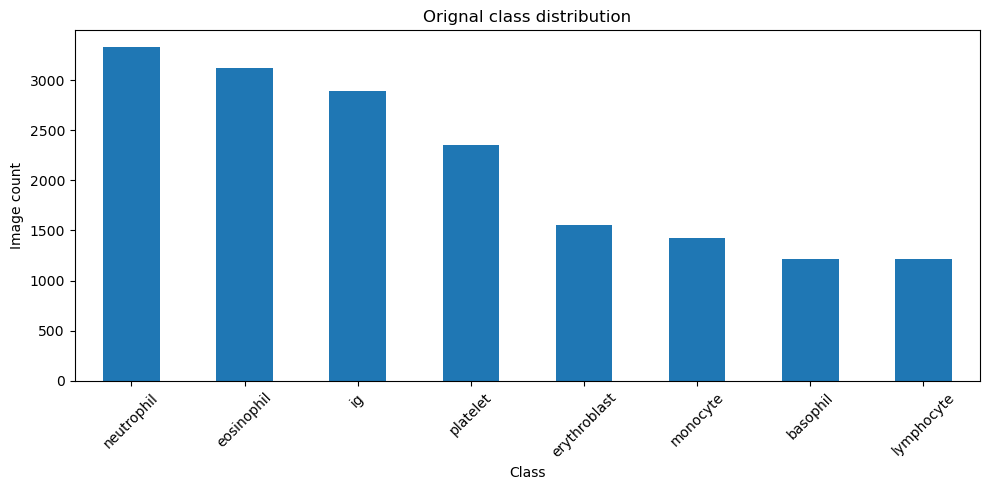

In [5]:
def collect_images(root: Path):
    items = []
    unreadable = []

    for path in root.rglob("*"):
        if not path.is_file():
            continue

        if not is_valid_image_path(path):
            continue

        class_name = path.parent.name

        img = cv2.imread(str(path), cv2.IMREAD_COLOR)

        if img is None:
            unreadable.append(str(path))
            continue

        h, w = img.shape[:2]

        items.append({
            "path": path,
            "class": class_name,
            "width": w,
            "height": h,
            "channels": img.shape[2] if len(img.shape) == 3 else 1
        })

    return items, unreadable


items, unreadable = collect_images(DATASET_DIR)

df = pd.DataFrame(items)

print("Readable image count:", len(df))
print("Unreadable file count:", len(unreadable))

display(df.head())

class_counts = df["class"].value_counts().sort_values(ascending=False)
display(class_counts.to_frame("count"))

plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar")
plt.title("Orignal class distribution")
plt.xlabel("Class")
plt.ylabel("Image count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
paths = df["path"].astype(str).values
labels = df["class"].values

train_val_x, test_x, train_val_y, test_y = train_test_split(
    paths,
    labels,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=labels
)

val_ratio_inside = VAL_RATIO / (1.0 - TEST_RATIO)

train_x, val_x, train_y, val_y = train_test_split(
    train_val_x,
    train_val_y,
    test_size=val_ratio_inside,
    random_state=SEED,
    stratify=train_val_y
)

train_df = pd.DataFrame({"path": train_x, "class": train_y})
val_df = pd.DataFrame({"path": val_x, "class": val_y})
test_df = pd.DataFrame({"path": test_x, "class": test_y})

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

split_summary = pd.concat([
    train_df["class"].value_counts().rename("train"),
    val_df["class"].value_counts().rename("val"),
    test_df["class"].value_counts().rename("test"),
], axis=1).fillna(0).astype(int)

display(split_summary)

Train: 11963
Val: 1710
Test: 3419


,train,val,test
class,,,
neutrophil,2330,333,666
eosinophil,2182,312,623
ig,2026,290,579
platelet,1643,235,470
erythroblast,1086,155,310
monocyte,994,142,284
basophil,852,122,244
lymphocyte,850,121,243


In [7]:
def resize_image(img, target_w=TARGET_WIDTH, target_h=TARGET_HEIGHT):
    return cv2.resize(img, (target_w, target_h), interpolation=cv2.INTER_AREA)


def safe_imwrite(path: Path, img, quality=95):
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.suffix.lower() in [".jpg", ".jpeg"]:
        cv2.imwrite(str(path), img, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
    else:
        cv2.imwrite(str(path), img)


def random_affine(img, rng):
    h, w = img.shape[:2]

    angle = rng.uniform(-28, 28)
    scale = rng.uniform(0.86, 1.16)

    tx = rng.uniform(-0.08, 0.08) * w
    ty = rng.uniform(-0.08, 0.08) * h

    shear_angle = math.radians(rng.uniform(-7, 7))

    center = (w / 2.0, h / 2.0)

    rot_mat = cv2.getRotationMatrix2D(center, angle, scale)

    shear_mat = np.array([
        [1, math.tan(shear_angle), 0],
        [0, 1, 0]
    ], dtype=np.float32)

    rot_mat_3 = np.vstack([rot_mat, [0, 0, 1]]).astype(np.float32)
    shear_mat_3 = np.vstack([shear_mat, [0, 0, 1]]).astype(np.float32)

    final_mat = (shear_mat_3 @ rot_mat_3)[:2]

    final_mat[0, 2] += tx
    final_mat[1, 2] += ty

    out = cv2.warpAffine(
        img,
        final_mat,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101
    )

    if rng.random() < 0.35:
        out = cv2.flip(out, 1)

    if rng.random() < 0.20:
        out = cv2.flip(out, 0)

    return out


def adjust_gamma(img, gamma):
    gamma = max(gamma, 1e-6)
    inv_gamma = 1.0 / gamma

    table = np.array([
        ((i / 255.0) ** inv_gamma) * 255
        for i in range(256)
    ]).astype("uint8")

    return cv2.LUT(img, table)


def random_light_and_stain(img, rng):
    out = img.copy()

    alpha = rng.uniform(0.78, 1.28)
    beta = rng.uniform(-28, 28)

    out = cv2.convertScaleAbs(out, alpha=alpha, beta=beta)

    if rng.random() < 0.75:
        gamma = rng.uniform(0.72, 1.38)
        out = adjust_gamma(out, gamma)

    hsv = cv2.cvtColor(out, cv2.COLOR_BGR2HSV).astype(np.float32)

    hsv[..., 0] = (hsv[..., 0] + rng.uniform(-5, 5)) % 180
    hsv[..., 1] *= rng.uniform(0.78, 1.24)
    hsv[..., 2] *= rng.uniform(0.86, 1.14)

    hsv[..., 1] = np.clip(hsv[..., 1], 0, 255)
    hsv[..., 2] = np.clip(hsv[..., 2], 0, 255)

    out = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

    if rng.random() < 0.35:
        lab = cv2.cvtColor(out, cv2.COLOR_BGR2LAB)
        l_channel, a_channel, b_channel = cv2.split(lab)

        clahe = cv2.createCLAHE(
            clipLimit=rng.uniform(1.2, 2.2),
            tileGridSize=(8, 8)
        )

        l_channel = clahe.apply(l_channel)

        lab = cv2.merge([l_channel, a_channel, b_channel])
        out = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    return out


def random_sensor_effects(img, rng):
    out = img.copy()
    h, w = out.shape[:2]

    if rng.random() < 0.30:
        k = rng.choice([3, 5])
        sigma = rng.uniform(0.15, 0.75)
        out = cv2.GaussianBlur(out, (k, k), sigmaX=sigma)

    if rng.random() < 0.45:
        noise_sigma = rng.uniform(2.0, 8.0)
        noise = np.random.normal(0, noise_sigma, out.shape).astype(np.float32)
        out = np.clip(out.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    if rng.random() < 0.35:
        x = np.linspace(-1, 1, w)
        y = np.linspace(-1, 1, h)

        xx, yy = np.meshgrid(x, y)

        cx = rng.uniform(-0.4, 0.4)
        cy = rng.uniform(-0.4, 0.4)

        rr = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)

        strength = rng.uniform(0.05, 0.22)
        mask = 1.0 - strength * rr
        mask = np.clip(mask, 0.72, 1.08).astype(np.float32)

        out = np.clip(out.astype(np.float32) * mask[..., None], 0, 255).astype(np.uint8)

    if rng.random() < 0.25:
        quality = rng.randint(72, 96)

        ok, encoded = cv2.imencode(
            ".jpg",
            out,
            [int(cv2.IMWRITE_JPEG_QUALITY), quality]
        )

        if ok:
            decoded = cv2.imdecode(encoded, cv2.IMREAD_COLOR)

            if decoded is not None:
                out = decoded

    return out


def augment_one(img, rng):
    img = resize_image(img)

    out = random_affine(img, rng)
    out = random_light_and_stain(out, rng)
    out = random_sensor_effects(out, rng)

    out = resize_image(out)

    return out

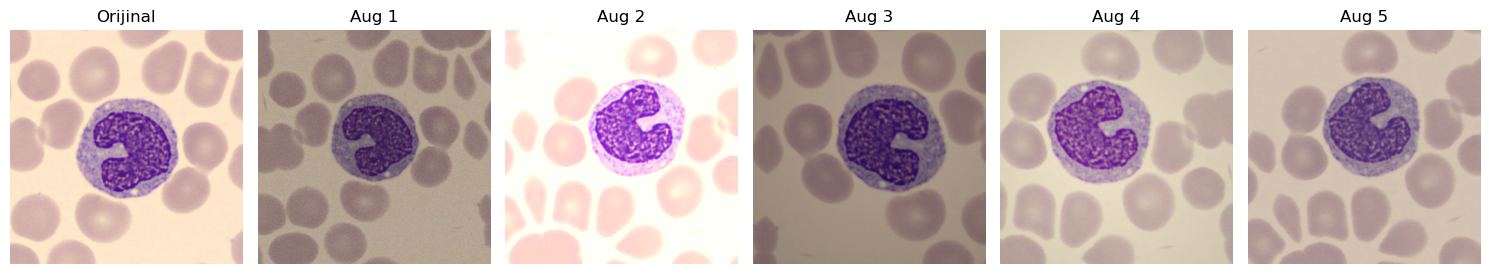

Class sample: monocyte


In [8]:
rng = random.Random(SEED)

sample_row = train_df.sample(1, random_state=SEED).iloc[0]
sample_img = cv2.imread(sample_row["path"])

sample_img = resize_image(sample_img)

augmented_examples = [sample_img]

for _ in range(5):
    augmented_examples.append(augment_one(sample_img, rng))

plt.figure(figsize=(15, 5))

for i, img in enumerate(augmented_examples):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 6, i + 1)
    plt.imshow(rgb)
    plt.axis("off")

    if i == 0:
        plt.title("Orijinal")
    else:
        plt.title(f"Aug {i}")

plt.tight_layout()
plt.show()

print("Class sample:", sample_row["class"])

In [10]:
def save_original_split(split_name, split_df):
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"{split_name} written"):
        src = Path(row["path"])
        class_name = row["class"]

        img = cv2.imread(str(src), cv2.IMREAD_COLOR)

        if img is None:
            continue

        img = resize_image(img)

        dst_dir = OUTPUT_DIR / split_name / class_name
        dst_dir.mkdir(parents=True, exist_ok=True)

        dst = dst_dir / f"{src.stem}.jpg"

        if dst.exists():
            unique = hashlib.md5(str(src).encode("utf-8")).hexdigest()[:8]
            dst = dst_dir / f"{src.stem}_{unique}.jpg"

        safe_imwrite(dst, img, quality=95)


if OVERWRITE_OUTPUT and OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

save_original_split("train", train_df)
save_original_split("val", val_df)
save_original_split("test", test_df)

print("Saved original splits to:", OUTPUT_DIR)

test written: 100%|██████████| 3419/3419 [00:05<00:00, 661.56it/s]

Saved original splits to: PBC_balanced_notebook


In [11]:
def balance_train_with_augmentation(train_df, target_count=None):
    rng = random.Random(SEED)
    np.random.seed(SEED)

    class_counts = train_df["class"].value_counts().sort_values(ascending=False)

    if target_count is None:
        target_count = int(class_counts.max())

    print("Train class counts:")
    display(class_counts.to_frame("before"))

    print("Target train class count:", target_count)

    manifest_rows = []

    for class_name in sorted(train_df["class"].unique()):
        class_df = train_df[train_df["class"] == class_name].reset_index(drop=True)

        current_count = len(class_df)
        needed = max(0, target_count - current_count)

        print(f"{class_name}: current={current_count}, to be produced={needed}")

        if needed == 0:
            continue

        for i in tqdm(range(needed), desc=f"{class_name} augment"):
            src_path = Path(class_df.iloc[i % current_count]["path"])

            img = cv2.imread(str(src_path), cv2.IMREAD_COLOR)

            if img is None:
                continue

            aug = augment_one(img, rng)

            out_name = f"{src_path.stem}_aug_{i:05d}.jpg"
            out_path = OUTPUT_DIR / "train" / class_name / out_name

            safe_imwrite(out_path, aug, quality=94)

            manifest_rows.append({
                "split": "train",
                "class": class_name,
                "source": str(src_path),
                "augmented": str(out_path)
            })

    manifest_df = pd.DataFrame(manifest_rows)

    return manifest_df, target_count


augmentation_manifest_df, final_target_count = balance_train_with_augmentation(
    train_df,
    target_count=TARGET_COUNT
)

display(augmentation_manifest_df.head())
print("Total number of generated augmented images:", len(augmentation_manifest_df))

Train class counts:


,before
class,
neutrophil,2330
eosinophil,2182
ig,2026
platelet,1643
erythroblast,1086
monocyte,994
basophil,852
lymphocyte,850


Target train class count: 2330
basophil: current=852, to be produced=1478


basophil augment: 100%|██████████| 1478/1478 [00:20<00:00, 72.41it/s]


eosinophil: current=2182, to be produced=148


...

monocyte augment: 100%|██████████| 1336/1336 [00:18<00:00, 73.00it/s]


neutrophil: current=2330, to be produced=0
platelet: current=1643, to be produced=687


platelet augment: 100%|██████████| 687/687 [00:08<00:00, 76.69it/s]


,split,class,source,augmented
0,train,basophil,pbc_extracted/PBC_dataset_normal_DIB/PBC_datas...,PBC_balanced_notebook/train/basophil/BA_120688...
1,train,basophil,pbc_extracted/PBC_dataset_normal_DIB/PBC_datas...,PBC_balanced_notebook/train/basophil/BA_566587...
2,train,basophil,pbc_extracted/PBC_dataset_normal_DIB/PBC_datas...,PBC_balanced_notebook/train/basophil/BA_725557...
3,train,basophil,pbc_extracted/PBC_dataset_normal_DIB/PBC_datas...,PBC_balanced_notebook/train/basophil/BA_442038...
4,train,basophil,pbc_extracted/PBC_dataset_normal_DIB/PBC_datas...,PBC_balanced_notebook/train/basophil/BA_661622...


Total number of generated augmented images: 6677


,split,class,count
0,train,basophil,2330
1,train,eosinophil,2330
2,train,erythroblast,2330
3,train,ig,2330
4,train,lymphocyte,2330
5,train,monocyte,2330
6,train,neutrophil,2330
7,train,platelet,2330
8,val,basophil,122
9,val,eosinophil,312


split,test,train,val
class,,,
basophil,244,2330,122
eosinophil,623,2330,312
erythroblast,310,2330,155
ig,579,2330,290
lymphocyte,243,2330,121
monocyte,284,2330,142
neutrophil,666,2330,333
platelet,470,2330,235


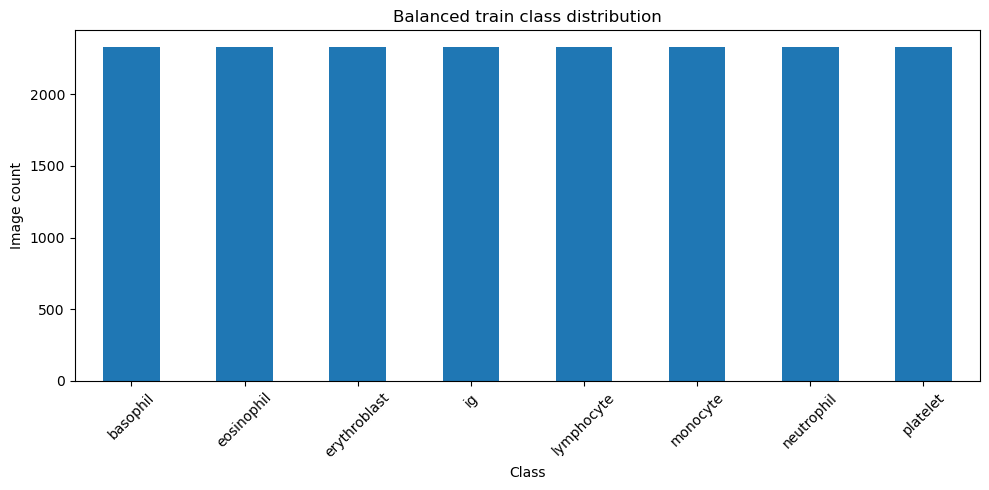

In [12]:
def count_output_images(output_dir: Path):
    rows = []

    for split_name in ["train", "val", "test"]:
        split_dir = output_dir / split_name

        if not split_dir.exists():
            continue

        for class_dir in sorted(split_dir.iterdir()):
            if not class_dir.is_dir():
                continue

            count = sum(
                1 for p in class_dir.iterdir()
                if p.is_file() and is_valid_image_path(p)
            )

            rows.append({
                "split": split_name,
                "class": class_dir.name,
                "count": count
            })

    return pd.DataFrame(rows)


report_df = count_output_images(OUTPUT_DIR)

display(report_df)

pivot_report = report_df.pivot(
    index="class",
    columns="split",
    values="count"
).fillna(0).astype(int)

display(pivot_report)

plt.figure(figsize=(10, 5))
pivot_report["train"].sort_values(ascending=False).plot(kind="bar")
plt.title("Balanced train class distribution")
plt.xlabel("Class")
plt.ylabel("Image count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
report_df.to_csv(OUTPUT_DIR / "dataset_report.csv", index=False)

augmentation_manifest_df.to_csv(
    OUTPUT_DIR / "augmentation_manifest.csv",
    index=False
)

if unreadable:
    with open(OUTPUT_DIR / "skipped_unreadable.txt", "w", encoding="utf-8") as f:
        for p in unreadable:
            f.write(p + "\n")

print("Done.")
print("Output folder:", OUTPUT_DIR)

print("Reports:")
print("-", OUTPUT_DIR / "dataset_report.csv")
print("-", OUTPUT_DIR / "augmentation_manifest.csv")

if unreadable:
    print("-", OUTPUT_DIR / "skipped_unreadable.txt")

Done.
Output folder: PBC_balanced_notebook
Reports:
- PBC_balanced_notebook/dataset_report.csv
- PBC_balanced_notebook/augmentation_manifest.csv


In [14]:
TRAIN_DIR = OUTPUT_DIR / "train"
VAL_DIR = OUTPUT_DIR / "val"
TEST_DIR = OUTPUT_DIR / "test"

print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Train: PBC_balanced_notebook/train
Validation: PBC_balanced_notebook/val
Test: PBC_balanced_notebook/test
